# Setup

In [59]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent

TRAJ_PATH = PROJECT_ROOT / "data" / "topic_trajectories.pkl"
FUTURE_MOVEMENT_PATH = PROJECT_ROOT / "data" / "future_topic_movement.csv"
LINEAGE_PATH = PROJECT_ROOT / "data" / "hdbscan_lineage.csv"

print("TRAJ_PATH exists:", TRAJ_PATH.exists(), TRAJ_PATH)
print("FUTURE_MOVEMENT_PATH exists:", FUTURE_MOVEMENT_PATH.exists(), FUTURE_MOVEMENT_PATH)
print("LINEAGE_PATH exists:", LINEAGE_PATH.exists(), LINEAGE_PATH)

TRAJ_PATH exists: True /Users/jonathanma/Desktop/DS Projects/diffusion-topic-evaluation/data/topic_trajectories.pkl
FUTURE_MOVEMENT_PATH exists: True /Users/jonathanma/Desktop/DS Projects/diffusion-topic-evaluation/data/future_topic_movement.csv
LINEAGE_PATH exists: True /Users/jonathanma/Desktop/DS Projects/diffusion-topic-evaluation/data/hdbscan_lineage.csv


In [60]:
with open(TRAJ_PATH, "rb") as f:
    topic_trajectories = pickle.load(f)

future_results_df = pd.read_csv(FUTURE_MOVEMENT_PATH)
lineage_df = pd.read_csv(LINEAGE_PATH)

print("Loaded trajectories:", len(topic_trajectories))
print("Future movement rows:", len(future_results_df))
print("Lineage rows:", len(lineage_df))

display(future_results_df.head())
display(lineage_df.head())

Loaded trajectories: 15
Future movement rows: 12
Lineage rows: 9


,topic_id,topic_label,latest_year,future_sigma,movement_norm,cosine_similarity_to_latest
0,0,Public Health & Workforce Impact,2022,0.08,0.298353,0.926739
1,1,Online Education & Training,2022,0.08,0.164708,0.986498
2,2,Clinical Virology & Infection,2022,0.08,0.099076,0.995004
3,3,Medical Imaging & Deep Learning,2022,0.08,0.072652,0.997410
4,4,Financial Markets & Economic Impact,2022,0.08,0.264548,0.971807


,lineage_id,year,cluster_id,n_docs
0,0,2020,0,6
1,1,2020,1,11
2,2,2020,2,31
3,3,2020,3,84
4,4,2020,4,9


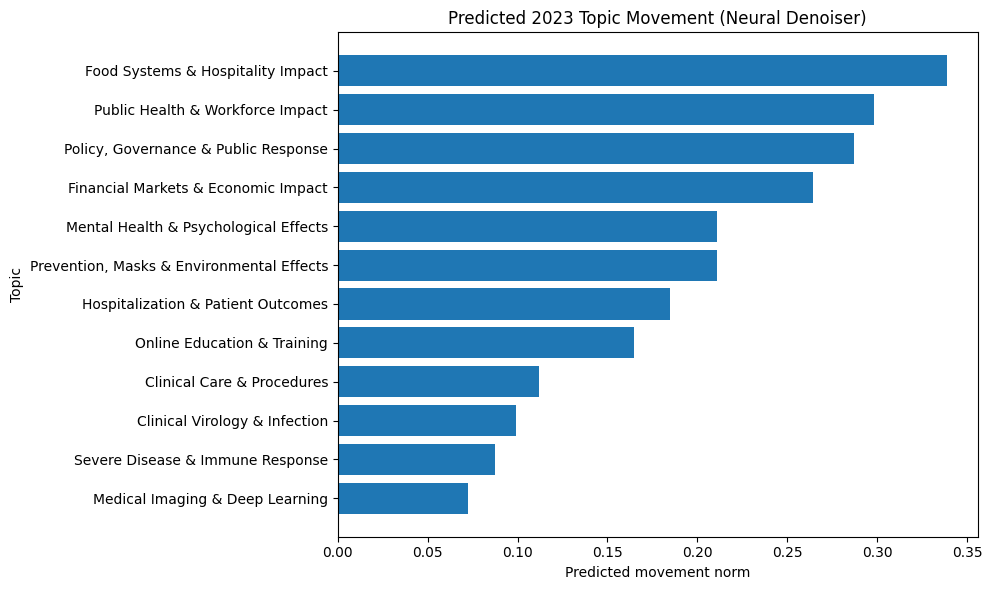

<Figure size 640x480 with 0 Axes>

In [90]:
# Bar Chart of Predicted future movement
plot_df = future_results_df.sort_values("movement_norm", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["topic_label"], plot_df["movement_norm"])
plt.xlabel("Predicted movement norm")
plt.ylabel("Topic")
plt.title("Predicted 2023 Topic Movement (Neural Denoiser)")
plt.tight_layout()
plt.show()
# plt.savefig(PROJECT_ROOT / "outputs" / "movement_norm.png", dpi=300, bbox_inches="tight")

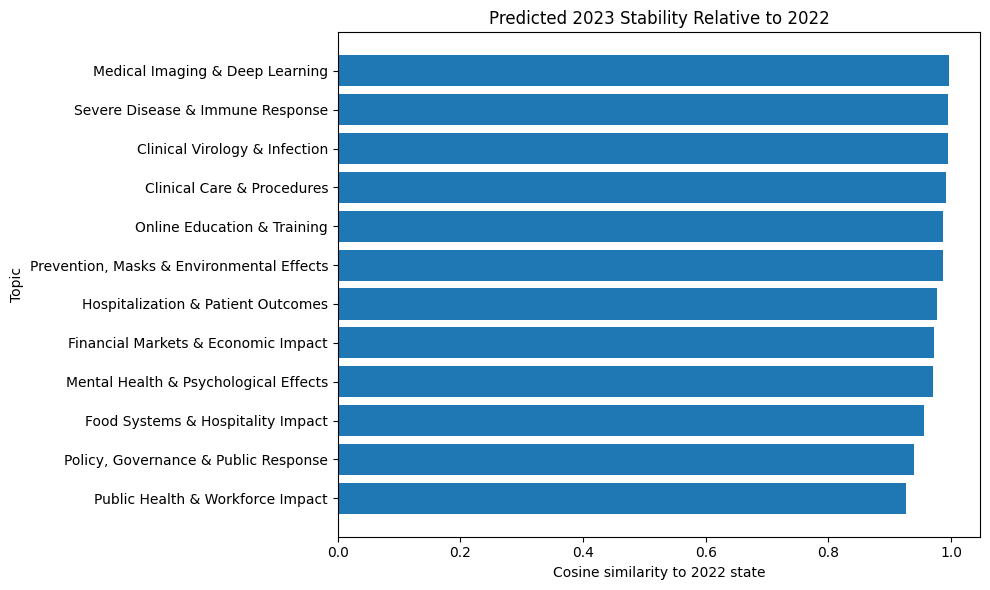

<Figure size 640x480 with 0 Axes>

In [91]:
# bar chart of cosine similarity to latest state
plot_df = future_results_df.sort_values("cosine_similarity_to_latest", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["topic_label"], plot_df["cosine_similarity_to_latest"])
plt.xlabel("Cosine similarity to 2022 state")
plt.ylabel("Topic")
plt.title("Predicted 2023 Stability Relative to 2022")
plt.tight_layout()
plt.show()
# plt.savefig(PROJECT_ROOT / "outputs" / "cosine_sim_latest.png", dpi=300, bbox_inches="tight")

# PCA Trajectory Plots

## Static

In [63]:
import textwrap

def wrap_label(s, width=28):
    return "\n".join(textwrap.wrap(s, width=width))

# Stable topic order for consistent coloring
topic_order = sorted(topic_trajectories.keys())

# Marker by year
year_markers = {
    2020: "o",
    2021: "s",
    2022: "^",
}

# Rebuild movement lookup
movement_lookup = future_results_df.set_index("topic_id")["movement_norm"].to_dict()

In [64]:
# Build PCA dataframe from trajectory points
all_points = []
meta = []

for topic_id, info in topic_trajectories.items():
    traj = info["trajectory"]
    years = info["years"]
    label = info["label"]

    for i, year in enumerate(years):
        all_points.append(traj[i])
        meta.append({
            "topic_id": topic_id,
            "label": label,
            "year": year,
            "movement_norm": movement_lookup.get(topic_id, np.nan),
        })

X_all = np.vstack(all_points)
meta_df = pd.DataFrame(meta)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_all)

meta_df["x"] = X_2d[:, 0]
meta_df["y"] = X_2d[:, 1]

print("Total trajectory points:", X_all.shape)
display(meta_df.head())

Total trajectory points: (42, 384)


,topic_id,label,year,movement_norm,x,y
0,0,Public Health & Workforce Impact,2020,0.298353,0.135508,0.083010
1,0,Public Health & Workforce Impact,2021,0.298353,0.101561,0.077770
2,0,Public Health & Workforce Impact,2022,0.298353,0.215858,0.082372
3,1,Online Education & Training,2020,0.164708,0.126310,0.018928
4,1,Online Education & Training,2021,0.164708,0.129933,-0.025799


In [65]:
TOP_K = 8

top_topic_ids = (
    future_results_df
    .sort_values("movement_norm", ascending=False)
    .head(TOP_K)["topic_id"]
    .tolist()
)

top_meta_df = meta_df[meta_df["topic_id"].isin(top_topic_ids)].copy()

print("Top topic IDs:", top_topic_ids)
display(
    future_results_df[future_results_df["topic_id"].isin(top_topic_ids)]
    .sort_values("movement_norm", ascending=False)
)

Top topic IDs: [9, 0, 11, 4, 5, 10, 14, 1]


,topic_id,topic_label,latest_year,future_sigma,movement_norm,cosine_similarity_to_latest
7,9,Food Systems & Hospitality Impact,2022,0.08,0.339089,0.955670
0,0,Public Health & Workforce Impact,2022,0.08,0.298353,0.926739
9,11,"Policy, Governance & Public Response",2022,0.08,0.287237,0.939108
4,4,Financial Markets & Economic Impact,2022,0.08,0.264548,0.971807
5,5,Mental Health & Psychological Effects,2022,0.08,0.211100,0.971219
8,10,"Prevention, Masks & Environmental Effects",2022,0.08,0.210937,0.986226
11,14,Hospitalization & Patient Outcomes,2022,0.08,0.184577,0.977872
1,1,Online Education & Training,2022,0.08,0.164708,0.986498


/var/folders/38/22n3rn6s7gjdhyf__np8757r0000gn/T/ipykernel_55778/1577607480.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(top_topic_ids))


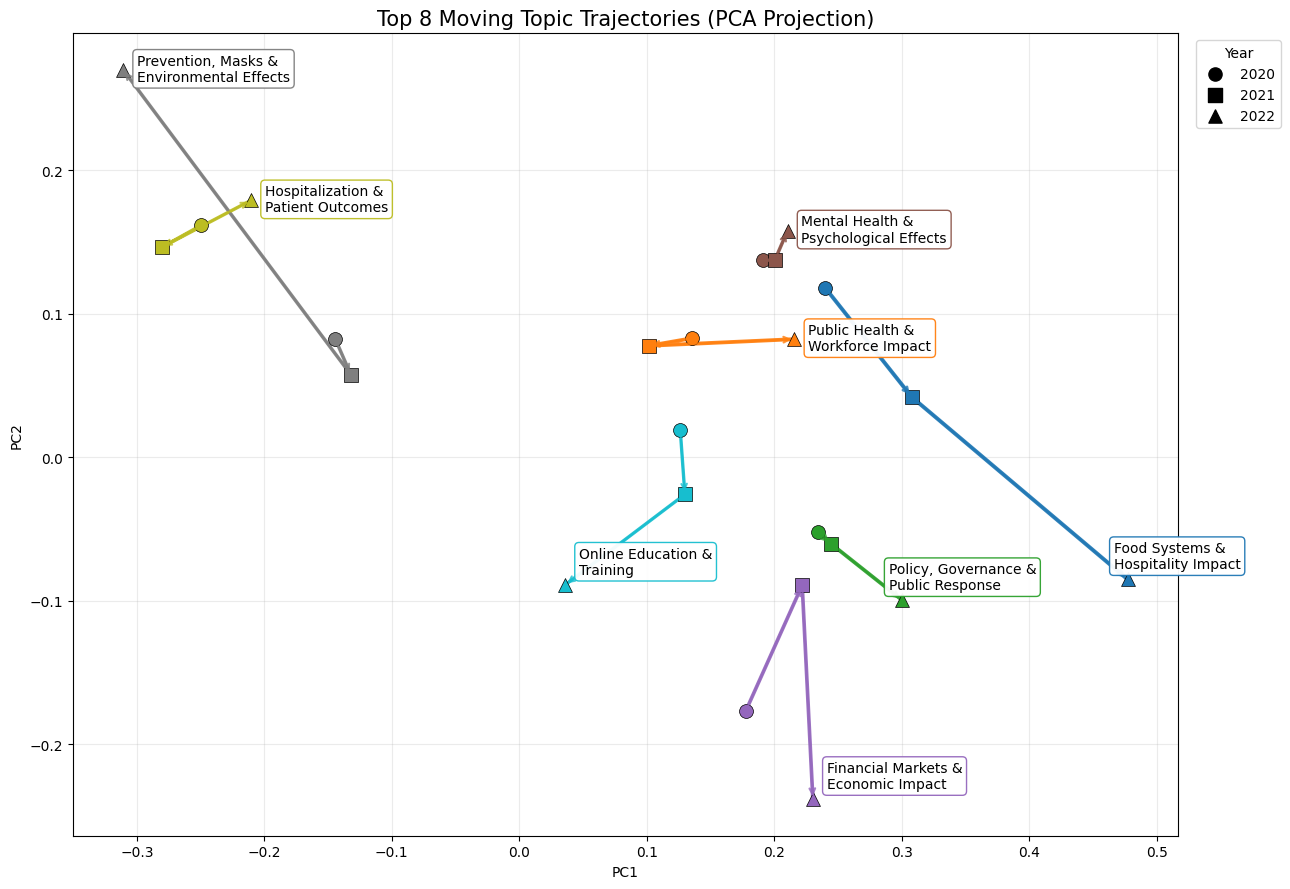

<Figure size 640x480 with 0 Axes>

In [92]:
plt.figure(figsize=(13, 9))

# color map (consistent across runs)
cmap = plt.cm.get_cmap("tab10", len(top_topic_ids))

for i, topic_id in enumerate(top_topic_ids):
    group = top_meta_df[top_meta_df["topic_id"] == topic_id].sort_values("year")

    x = group["x"].values
    y = group["y"].values
    label = group["label"].iloc[0]
    movement = group["movement_norm"].iloc[0]

    color = cmap(i)

    # thicker lines = more movement
    lw = 2 + 2.5 * movement

    # trajectory line
    plt.plot(x, y, linewidth=lw, alpha=0.9, color=color)

    # markers
    for _, row in group.iterrows():
        plt.scatter(
            row["x"], row["y"],
            marker=year_markers.get(row["year"], "o"),
            s=100,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            zorder=3
        )

    # arrows
    for j in range(len(group) - 1):
        plt.annotate(
            "",
            xy=(x[j + 1], y[j + 1]),
            xytext=(x[j], y[j]),
            arrowprops=dict(
                arrowstyle="->",
                lw=lw * 0.6,
                color=color,
                alpha=0.8
            )
        )

    # label (adaptive offset to reduce overlap)
    last = group.iloc[-1]
    dx = 10 if last["x"] < 0.3 else -10
    dy = 8 if last["y"] < 0 else -8

    plt.annotate(
        wrap_label(label, width=22),
        xy=(last["x"], last["y"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec=color,
            alpha=0.95
        )
    )

# legend for years
for year, marker in year_markers.items():
    plt.scatter([], [], marker=marker, s=90, label=str(year), color="black")

plt.title("Top 8 Moving Topic Trajectories (PCA Projection)", fontsize=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Year", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
# plt.savefig(PROJECT_ROOT / "outputs" / "top8_pca.png", dpi=300, bbox_inches="tight")

## Interactive

In [71]:
import plotly.graph_objects as go

fig = go.Figure()

for i, topic_id in enumerate(top_topic_ids):
    group = top_meta_df[top_meta_df["topic_id"] == topic_id].sort_values("year")

    label = group["label"].iloc[0]
    movement = group["movement_norm"].iloc[0]

    x = group["x"].values
    y = group["y"].values

    # main trajectory line
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode="lines",
        name=label,
        line=dict(width=2 + 2.5 * movement),
        hoverinfo="skip"
    ))

    # markers (start vs end emphasized)
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode="markers",
        showlegend=False,
        marker=dict(
            size=[8, 10, 14],  # increasing size over time
        ),
        hovertemplate=(
            f"<b>{label}</b><br>"
            "Year: %{customdata}<br>"
            "PC1: %{x:.3f}<br>"
            "PC2: %{y:.3f}<br>"
            f"Movement norm: {movement:.3f}<extra></extra>"
        ),
        customdata=group["year"]
    ))

    # arrows (direction)
    for j in range(len(x) - 1):
        fig.add_annotation(
            x=x[j + 1],
            y=y[j + 1],
            ax=x[j],
            ay=y[j],
            xref="x",
            yref="y",
            axref="x",
            ayref="y",
            showarrow=True,
            arrowhead=3,
            arrowsize=1.2,
            arrowwidth=1.5,
            opacity=0.7
        )

fig.update_layout(
    title="Interactive Top 8 Topic Trajectories (PCA Projection)",
    xaxis_title="PC1",
    yaxis_title="PC2",
    template="plotly_white",
    width=1050,
    height=800,
    legend_title="Topic"
)

fig.show()

# Linneage Plot

In [72]:
lineage_summary = (
    lineage_df.groupby("lineage_id")
    .agg(
        start_year=("year", "min"),
        end_year=("year", "max"),
        n_years=("year", "nunique"),
        total_docs=("n_docs", "sum"),
    )
    .reset_index()
)

def classify_lineage(row):
    if row["n_years"] >= 2:
        return "persistent"
    elif row["start_year"] == 2020 and row["end_year"] == 2020:
        return "dies"
    elif row["start_year"] == 2021 and row["end_year"] == 2021:
        return "born"
    else:
        return "other"

lineage_summary["status"] = lineage_summary.apply(classify_lineage, axis=1)

display(lineage_summary)

,lineage_id,start_year,end_year,n_years,total_docs,status
0,0,2020,2021,2,19,persistent
1,1,2020,2020,1,11,dies
2,2,2020,2020,1,31,dies
3,3,2020,2021,2,208,persistent
4,4,2020,2020,1,9,dies
5,5,2021,2021,1,7,born
6,6,2021,2021,1,8,born


In [73]:
import sqlite3

DB_PATH = PROJECT_ROOT / "db" / "app.db"

conn = sqlite3.connect(DB_PATH)

docs_text_df = pd.read_sql_query("""
    SELECT
        id AS document_id,
        publication_year,
        title,
        clean_text
    FROM documents
""", conn)

conn.close()

display(docs_text_df.head())

,document_id,publication_year,title,clean_text
0,1,2020,Study protocol: Comparison of different risk p...,Study protocol: Comparison of different risk p...
1,2,2020,"Mental health, sleep quality and quality of li...","Mental health, sleep quality and quality of li..."
2,3,2020,Parent perspectives on food allergy management...,Parent perspectives on food allergy management...
3,4,2020,COVID-19 critical illness in Sweden: character...,COVID-19 critical illness in Sweden: character...
4,5,2020,Geolocated Twitter-based population mobility i...,Geolocated Twitter-based population mobility i...


In [50]:
HDBSCAN_ASSIGNMENTS_PATH = PROJECT_ROOT / "data" / "hdbscan_assignments.csv"

hdbscan_assignments_df = pd.read_csv(HDBSCAN_ASSIGNMENTS_PATH)

print("Assignments loaded:", hdbscan_assignments_df.shape)
display(hdbscan_assignments_df.head())

Assignments loaded: (738, 3)


,document_id,publication_year,hdbscan_label
0,1,2020,3
1,2,2020,2
2,3,2020,-1
3,4,2020,-1
4,5,2020,1


In [74]:
lineage_docs_df = (
    lineage_df.merge(
        hdbscan_assignments_df,
        left_on=["year", "cluster_id"],
        right_on=["publication_year", "hdbscan_label"],
        how="left"
    )
    .merge(
        docs_text_df,
        on="document_id",
        how="left"
    )
)

# 🔹 Remove HDBSCAN noise points (-1) and missing joins
lineage_docs_df = lineage_docs_df[
    (lineage_docs_df["hdbscan_label"] != -1) &
    (lineage_docs_df["document_id"].notna())
].copy()

print("Lineage-doc rows:", lineage_docs_df.shape)
display(lineage_docs_df.head())

Lineage-doc rows: (293, 10)


,lineage_id,year,cluster_id,n_docs,document_id,publication_year_x,hdbscan_label,publication_year_y,title,clean_text
0,0,2020,0,6,153,2020,0,2020,Explainable Machine Learning for Early Assessm...,Explainable Machine Learning for Early Assessm...
1,0,2020,0,6,154,2020,0,2020,2019 Novel Coronavirus-Infected Pneumonia on C...,2019 Novel Coronavirus-Infected Pneumonia on C...
2,0,2020,0,6,169,2020,0,2020,Artificial Intelligence Applied to Chest X-Ray...,Artificial Intelligence Applied to Chest X-Ray...
3,0,2020,0,6,173,2020,0,2020,Deep Convolutional Approaches for the Analysis...,Deep Convolutional Approaches for the Analysis...
4,0,2020,0,6,628,2020,0,2020,Artificial Intelligence and COVID-19: Deep Lea...,Artificial Intelligence and COVID-19: Deep Lea...


In [75]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "covid", "19", "covid19", "covid-19",
    "sars", "cov", "sars-cov", "sars-cov-2",
    "pandemic", "coronavirus", "disease",
    "study", "studies", "using", "use",
    "background", "objective", "objectives",
    "methods", "results", "conclusion", "conclusions",
    "analysis", "review", "health"
})

bad_terms = {
    "covid", "19", "covid 19", "sars", "cov", "sars cov",
    "pandemic", "coronavirus disease"
}

def make_lineage_label_from_titles(lineage_id, titles, top_n=4):
    titles = [t for t in titles if isinstance(t, str) and t.strip()]

    if len(titles) == 0:
        return f"Lineage {int(lineage_id)}: unlabeled cluster"

    vectorizer = CountVectorizer(
        stop_words=list(custom_stopwords),
        max_features=100,
        ngram_range=(1, 2),
        min_df=1
    )

    X = vectorizer.fit_transform(titles)
    terms = np.array(vectorizer.get_feature_names_out())
    scores = np.asarray(X.sum(axis=0)).ravel()

    ranked_terms = terms[np.argsort(scores)[::-1]].tolist()
    cleaned_terms = [t for t in ranked_terms if t not in bad_terms][:top_n]

    if len(cleaned_terms) == 0:
        return f"Lineage {int(lineage_id)}: unlabeled cluster"

    return f"Lineage {int(lineage_id)}: " + ", ".join(cleaned_terms)

lineage_name_rows = []

for lineage_id, group in lineage_docs_df.groupby("lineage_id"):
    lineage_name_rows.append({
        "lineage_id": int(lineage_id),
        "lineage_name": make_lineage_label_from_titles(
            lineage_id,
            group["title"].dropna().tolist(),
            top_n=4
        )
    })

lineage_name_df = pd.DataFrame(lineage_name_rows)

display(lineage_name_df)

,lineage_id,lineage_name
0,0,"Lineage 0: chest, images, ray, chest ray"
1,1,"Lineage 1: spread, networks, mobile, based"
2,2,"Lineage 2: sectional, cross, cross sectional, ..."
3,3,"Lineage 3: patients, care, clinical, impact"
4,4,"Lineage 4: digital, data, twitter, infodemic"
5,5,"Lineage 5: engineering, online, biomedical, bi..."
6,6,"Lineage 6: stock, financial, markets, evidence"


In [76]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "covid", "19", "covid19", "covid-19",
    "sars", "cov", "sars-cov", "sars-cov-2",
    "pandemic", "coronavirus", "disease",
    "study", "studies", "using", "use",
    "background", "objective", "objectives",
    "methods", "results", "conclusion", "conclusions",
    "analysis", "review"
})

In [77]:
def make_lineage_label_from_titles(lineage_id, titles, top_n=4):
    titles = [t for t in titles if isinstance(t, str) and t.strip()]

    if len(titles) == 0:
        return f"Lineage {int(lineage_id)}: unlabeled cluster"

    vectorizer = CountVectorizer(
        stop_words=list(custom_stopwords),
        max_features=100,
        ngram_range=(1, 2),
        min_df=1
    )

    X = vectorizer.fit_transform(titles)
    terms = np.array(vectorizer.get_feature_names_out())
    scores = np.asarray(X.sum(axis=0)).ravel()

    # rank terms
    ranked_terms = terms[np.argsort(scores)[::-1]].tolist()

    # additional filtering (lightweight)
    bad_terms = {
        "covid", "19", "covid 19", "sars", "cov", "sars cov",
        "pandemic", "coronavirus disease"
    }

    top_terms = [t for t in ranked_terms if t not in bad_terms][:top_n]

    if len(top_terms) == 0:
        return f"Lineage {int(lineage_id)}: unlabeled cluster"

    return f"Lineage {int(lineage_id)}: " + ", ".join(top_terms)

In [78]:
lineage_name_rows = []

for lineage_id, group in lineage_docs_df.groupby("lineage_id"):
    lineage_name_rows.append({
        "lineage_id": int(lineage_id),
        "lineage_name": make_lineage_label_from_titles(
            lineage_id,
            group["title"].dropna().tolist(),
            top_n=4
        )
    })

lineage_name_df = pd.DataFrame(lineage_name_rows)

display(lineage_name_df)

,lineage_id,lineage_name
0,0,"Lineage 0: chest, images, ray, chest ray"
1,1,"Lineage 1: spread, networks, mobile, based"
2,2,"Lineage 2: sectional, cross sectional, health,..."
3,3,"Lineage 3: patients, care, clinical, health"
4,4,"Lineage 4: digital, data, twitter, infodemic"
5,5,"Lineage 5: engineering, online, biomedical, bi..."
6,6,"Lineage 6: stock, financial, markets, evidence"


In [81]:
lineage_plot_df = lineage_df.merge(
    lineage_summary[["lineage_id", "status", "total_docs"]],
    on="lineage_id",
    how="left"
).merge(
    lineage_name_df,
    on="lineage_id",
    how="left"
)

# fallback for missing names
lineage_plot_df["lineage_name"] = lineage_plot_df["lineage_name"].fillna(
    lineage_plot_df["lineage_id"].apply(lambda x: f"Lineage {int(x)}")
)

display(lineage_plot_df.sort_values(["lineage_id", "year"]))

,lineage_id,year,cluster_id,n_docs,status,total_docs,lineage_name
0,0,2020,0,6,persistent,19,"Lineage 0: chest, images, ray, chest ray"
8,0,2021,3,13,persistent,19,"Lineage 0: chest, images, ray, chest ray"
1,1,2020,1,11,dies,11,"Lineage 1: spread, networks, mobile, based"
2,2,2020,2,31,dies,31,"Lineage 2: sectional, cross sectional, health,..."
3,3,2020,3,84,persistent,208,"Lineage 3: patients, care, clinical, health"
7,3,2021,2,124,persistent,208,"Lineage 3: patients, care, clinical, health"
4,4,2020,4,9,dies,9,"Lineage 4: digital, data, twitter, infodemic"
5,5,2021,0,7,born,7,"Lineage 5: engineering, online, biomedical, bi..."
6,6,2021,1,8,born,8,"Lineage 6: stock, financial, markets, evidence"


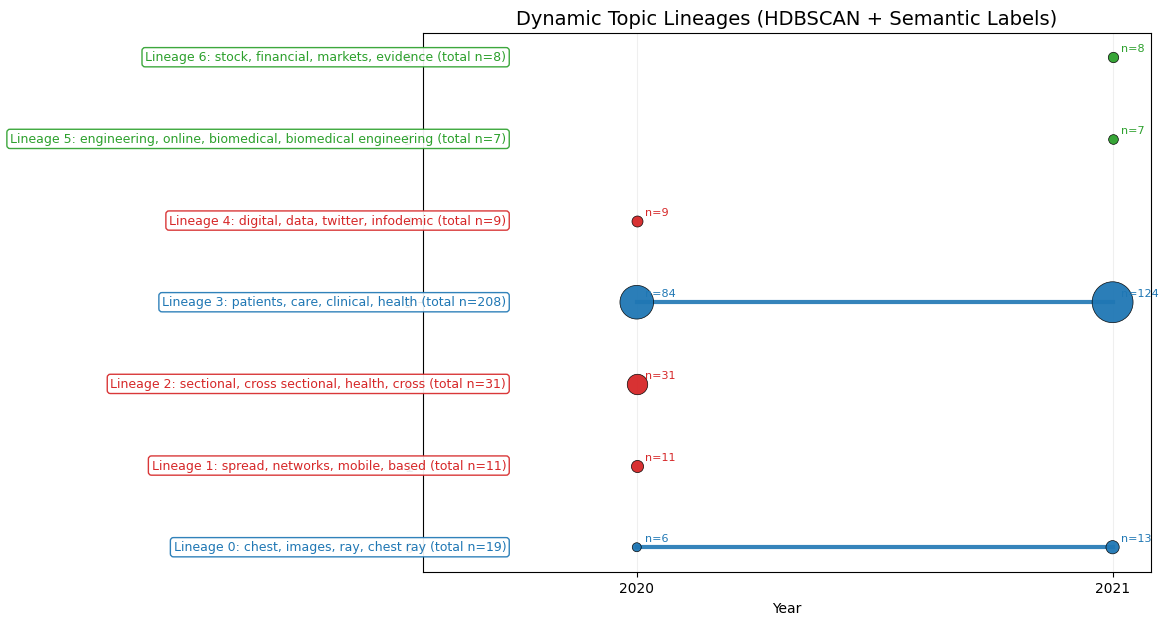

<Figure size 640x480 with 0 Axes>

In [93]:
status_colors = {
    "persistent": "tab:blue",
    "dies": "tab:red",
    "born": "tab:green",
    "other": "gray",
}

plt.figure(figsize=(14, 7))

for lineage_id, group in lineage_plot_df.groupby("lineage_id"):
    group = group.sort_values("year")

    status = group["status"].iloc[0]
    color = status_colors.get(status, "gray")

    lineage_name = group["lineage_name"].iloc[0]
    total_docs = int(group["total_docs"].iloc[0])

    x = group["year"].values
    y = np.full(len(group), lineage_id)

    # emphasize persistent major lineages a bit more
    line_width = 3 if status == "persistent" else 2

    # draw connection line only if lineage persists across years
    if len(group) > 1:
        plt.plot(x, y, color=color, linewidth=line_width, alpha=0.9)

    # draw nodes (size = document count)
    plt.scatter(
        x,
        y,
        s=group["n_docs"].values * 7,
        color=color,
        alpha=0.95,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    # annotate nodes with doc counts
    for _, row in group.iterrows():
        plt.annotate(
            f'n={int(row["n_docs"])}',
            xy=(row["year"], lineage_id),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
            color=color
        )

    # semantic lineage label on the left
    plt.annotate(
        f"{lineage_name} (total n={total_docs})",
        xy=(2019.74, lineage_id),
        xytext=(-5, 0),
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=9,
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec=color,
            alpha=0.92
        )
    )

plt.xlim(2019.55, 2021.08)
plt.xticks([2020, 2021])
plt.xlabel("Year")
plt.title("Dynamic Topic Lineages (HDBSCAN + Semantic Labels)", fontsize=14)

plt.grid(axis="x", alpha=0.2)
plt.subplots_adjust(left=0.38)
plt.show()
# plt.savefig(PROJECT_ROOT / "outputs" / "linneage.png", dpi=300, bbox_inches="tight")

## Interactive

In [86]:
import plotly.graph_objects as go

lineage_plot_df["hover_text"] = (
    "<b>" + lineage_plot_df["lineage_name"] + "</b><br>" +
    "Year: " + lineage_plot_df["year"].astype(str) + "<br>" +
    "Cluster ID: " + lineage_plot_df["cluster_id"].astype(str) + "<br>" +
    "Docs in node: " + lineage_plot_df["n_docs"].astype(str) + "<br>" +
    "Total docs in lineage: " + lineage_plot_df["total_docs"].astype(str) + "<br>" +
    "Status: " + lineage_plot_df["status"].astype(str)
)

display(lineage_plot_df.head())

,lineage_id,year,cluster_id,n_docs,status,total_docs,lineage_name,hover_text
0,0,2020,0,6,persistent,19,"Lineage 0: chest, images, ray, chest ray","<b>Lineage 0: chest, images, ray, chest ray</b..."
1,1,2020,1,11,dies,11,"Lineage 1: spread, networks, mobile, based","<b>Lineage 1: spread, networks, mobile, based<..."
2,2,2020,2,31,dies,31,"Lineage 2: sectional, cross sectional, health,...","<b>Lineage 2: sectional, cross sectional, heal..."
3,3,2020,3,84,persistent,208,"Lineage 3: patients, care, clinical, health","<b>Lineage 3: patients, care, clinical, health..."
4,4,2020,4,9,dies,9,"Lineage 4: digital, data, twitter, infodemic","<b>Lineage 4: digital, data, twitter, infodemi..."


In [89]:
status_colors = {
    "persistent": "blue",
    "dies_after_2020": "red",
    "dies": "red",
    "born_in_2021": "green",
    "birth": "green",
    "other": "gray",
}

fig = go.Figure()

for lineage_id, group in lineage_plot_df.groupby("lineage_id"):
    group = group.sort_values("year")

    status = group["status"].iloc[0]
    color = status_colors.get(status, "gray")
    lineage_name = group["lineage_name"].iloc[0]

    fig.add_trace(go.Scatter(
        x=group["year"],
        y=[lineage_id] * len(group),
        mode="lines+markers+text",
        name=lineage_name,
        text=[f'n={n}' for n in group["n_docs"]],
        textposition="top center",
        hovertext=group["hover_text"],
        hoverinfo="text",
        line=dict(color=color, width=3 if status == "persistent" else 2),
        marker=dict(
            color=color,
            size=group["n_docs"] * 0.45 + 10,
            line=dict(color="black", width=0.5)
        )
    ))

fig.update_layout(
    title="Interactive Dynamic Topic Lineages (HDBSCAN + Semantic Labels)",
    xaxis_title="Year",
    yaxis_title="Lineage ID",
    template="plotly_white",
    width=1150,
    height=750,
    legend_title="Lineage",
    xaxis=dict(
        tickmode="array",
        tickvals=sorted(lineage_plot_df["year"].unique())
    )
)

fig.show()